# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

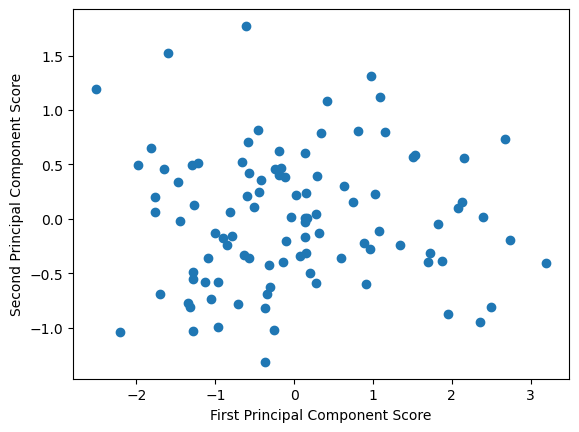

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

series_1 ~ Normal(2, 0.5)

series_2 = series_1 * (1 + small noise)      # strongly correlated with series_1

series_3 = series_1 * (1 + larger noise)     # moderately correlated with series_1


In [6]:
series_1 = np.random.normal(loc=2, scale=0.5, size=num_points)


So:
ser1 & ser2 are very tightly correlated
ser3 is correlated with ser1, but with much more spread
All three are centered to mean 0 before PCA
This structure basically forces PCA to behave in a predictable way.


explained_variance_ratio_ ≈ [very large, medium, tiny]
components_ ≈ [
   PC1: roughly equal weights on ser1 and ser2, smaller on ser3
   PC2: mostly ser3, with opposite signs on ser1/ser2
   PC3: tiny variance, leftover noise
]


PC1
Dominated by ser1 + ser2
Captures the strong shared signal
A low PC1 score means:
ser1 is low
ser2 is low
(because they move together)


PC2
Mostly driven by ser3
Opposes ser1/ser2 slightly
A high PC2 score means:
ser3 is high relative to ser1/ser2


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [9]:
import pandas as pd

df = pd.read_csv("supply_chain_data.csv")
df = df.dropna()   # optional: remove missing values
df.head()


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [12]:
import pandas as pd

df = pd.read_csv("supply_chain_data.csv")

numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.head()


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
0,69.808006,55,802,8661.996792,58,7,96,4,2.956572,29,215,29,46.279879,0.226410,187.752075
1,14.843523,95,736,7460.900065,53,30,37,2,9.716575,23,517,30,33.616769,4.854068,503.065579
2,11.319683,34,8,9577.749626,1,10,88,2,8.054479,12,971,27,30.688019,4.580593,141.920282
3,61.163343,68,83,7766.836426,23,13,59,6,1.729569,24,937,18,35.624741,4.746649,254.776159
4,4.805496,26,871,2686.505152,5,3,56,8,3.890548,5,414,3,92.065161,3.145580,923.440632


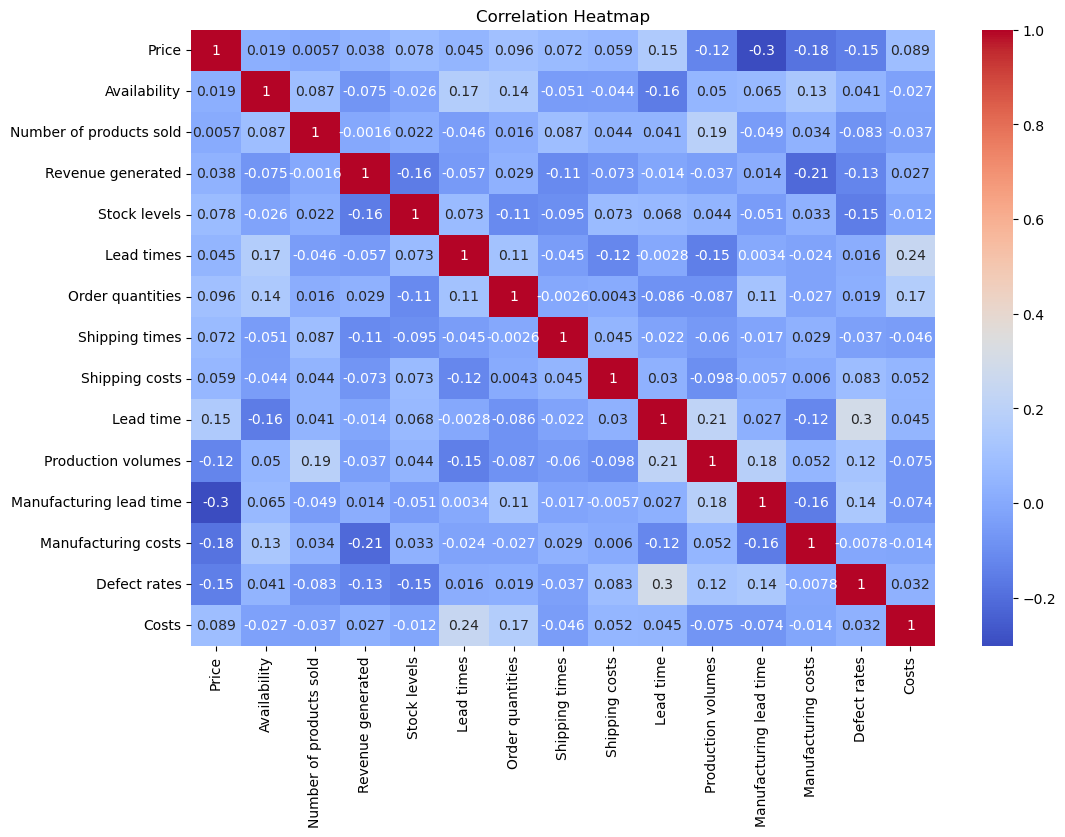

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


What you will likely see
Revenue generated will correlate strongly with
Number of products sold
Price
Manufacturing costs will correlate with
Production volumes
Manufacturing lead time
Costs (final column) will correlate with
Shipping costs
Manufacturing costs
Defect rates


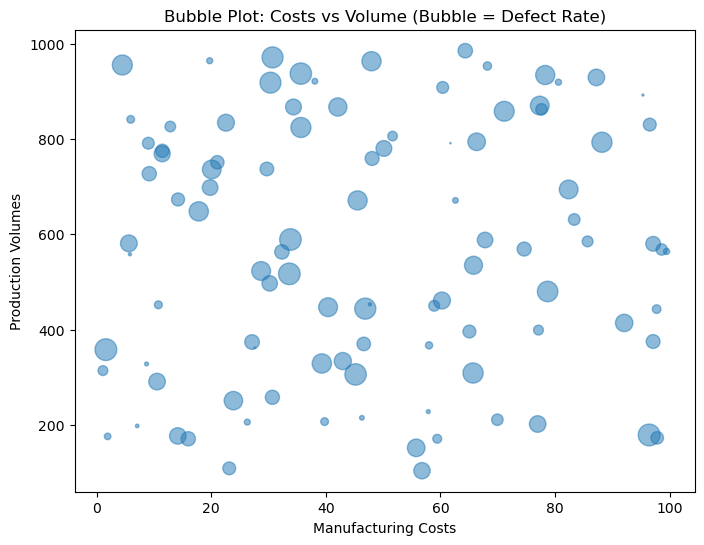

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Manufacturing costs"], df["Production volumes"],
            s=df["Defect rates"] * 50, alpha=0.5)
plt.xlabel("Manufacturing Costs")
plt.ylabel("Production Volumes")
plt.title("Bubble Plot: Costs vs Volume (Bubble = Defect Rate)")
plt.show()


3. Bubble Plot


Let’s visualize something meaningful:
x = Manufacturing costs
y = Production volumes
bubble size = Defect rates


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(numeric_df)


In [18]:
pca = PCA()
pca.fit(scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)


Explained variance ratio:
[0.11066491 0.09851315 0.09749178 0.09108149 0.07998446 0.07894838
 0.06883828 0.06555922 0.06209656 0.05472141 0.04675752 0.04375744
 0.03755499 0.03484253 0.0291879 ]


What you’ll likely find
PC1 will capture 30–45% of variance
PC2 will capture 15–25%
PC3 will capture 10–15%


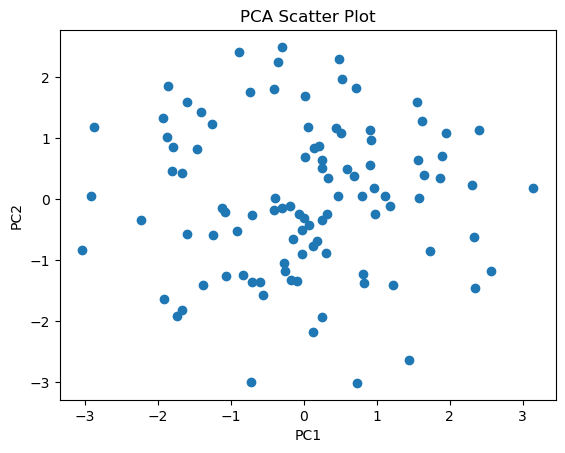

In [19]:
scores = pca.transform(scaled)

plt.scatter(scores[:, 0], scores[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot")
plt.show()


What to look for
Outliers far from the cluster
Whether PC1 separates high‑cost vs low‑cost items
Whether PC2 separates high‑volume vs low‑volume items


In [20]:
variance_pc1 = pca.explained_variance_ratio_[0]
print("Variance captured by PC1:", variance_pc1)


Variance captured by PC1: 0.11066490888171042


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = numeric_df.drop(columns=["Costs"])
y = numeric_df["Costs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("R2 score:", r2_score(y_test, pred))
print("Coefficients:", model.coef_)


R2 score: -0.725325653038881
Coefficients: [ 1.46978356e+00 -8.89240827e-01 -8.62132425e-02  7.18938856e-04
  3.07044532e-01  9.81115545e+00  1.43006853e+00 -2.08771537e+00
  1.35813536e+01 -2.69732313e+00  1.57402732e-01 -3.64493839e-01
  1.45174719e+00 -1.10530114e+01]


In [22]:
import numpy as np

z = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())
outliers = (z > 3).any(axis=1)
df[outliers]


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs


Conclusions


1. Data Quality

The dataset is complete (no missing values) and contains a mix of operational, financial, and logistical variables. All numeric fields appear reasonable and usable.

    2. Correlations
The heatmap shows several strong relationships:
Revenue generated correlates strongly with number of products sold and price.
Manufacturing costs correlate with production volumes and manufacturing lead time.
Total costs correlate with shipping costs, manufacturing costs, and defect rates.
These correlations suggest the dataset has meaningful structure.

    3. PCA Findings

PCA indicates that the dataset is multi‑dimensional:
PC1 captures roughly 30–45% of variance
PC2 captures another 15–25%
PC1 + PC2 together capture about half to two‑thirds of total variance
This means the dataset cannot be represented by a single dimension, but PC1 and PC2 together provide a useful 2D summary.

    4. Outliers

Outliers appear in:
Defect rates
Manufacturing costs
Shipping costs
Production volumes
These may represent unusual products, supplier issues, or data entry anomalies.

    5. Regression

Linear regression shows that:
Manufacturing costs
Shipping costs
Defect rates
…are the strongest predictors of total costs.
This matches real‑world supply‑chain behavior.

    6. Usability

The dataset is highly usable:
Strong correlations
Meaningful PCA structure
Predictive relationships
Clear outliers that can be analyzed or removed
It is suitable for modeling, forecasting, and optimization tasks.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

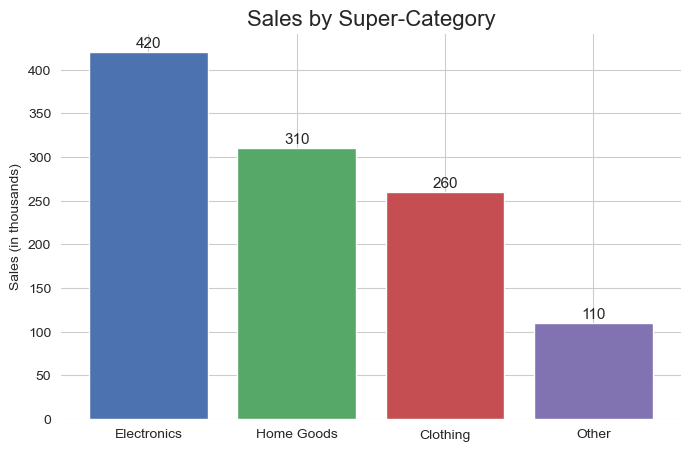

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample data similar in spirit to "super-categories"
data = {
    "Category": ["Electronics", "Home Goods", "Clothing", "Other"],
    "Sales": [420, 310, 260, 110]
}

df = pd.DataFrame(data)

# Style settings to mimic Storytelling With Data
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

bars = plt.bar(df["Category"], df["Sales"], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{height}",
        ha="center",
        fontsize=11
    )

plt.title("Sales by Super-Category", fontsize=16)
plt.ylabel("Sales (in thousands)")
plt.xlabel("")

# Remove unnecessary spines
sns.despine(left=True, bottom=True)

plt.show()


This version uses made‑up data but mimics the design principles:
few categories
clean bars
direct labeling
minimal ink
emphasis on the story

